# Visualize for a Sweep of Separations

In [1]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

## Get all the data from the files

In [2]:
separations = []
heights = []
runs = ["5-2","10","20","30","40","50","60"]

ratios = []
e_js,e_cs = [],[]
integrated_volumes = []
coeffs_array = []
n = 0

for run in runs:
    with open(f"./allplots/sweep_height3/height{run}/results.pkl", 'rb') as f:
        pickled_obj= pickle.load(f)
        print(f"Pickled object loaded Run{run}")
        E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
        separations.append(pickled_obj["parameters"]["separation"])
        heights.append(pickled_obj["parameters"]["sidelenZ"])
        ratios.append(E_J/E_C)
        e_js.append(E_J)
        e_cs.append(E_C)
        integrated_volumes.append(pickled_obj["integrated_volume"])
        coeffs_array.append(pickled_obj["coeffs"])
        n = pickled_obj["n"]

# Sort by separations, and sort the ratios the same way
separations, ratios, e_js, e_cs, integrated_volumes, coeffs_array = zip(*sorted(zip(separations, ratios, e_js, e_cs, integrated_volumes, coeffs_array)))

Pickled object loaded Run5-2
Pickled object loaded Run10


Pickled object loaded Run20
Pickled object loaded Run30
Pickled object loaded Run40
Pickled object loaded Run50
Pickled object loaded Run60


## Plot EJ/EC vs Separation

Degree of Polynomial Fit: 2.288669073493158


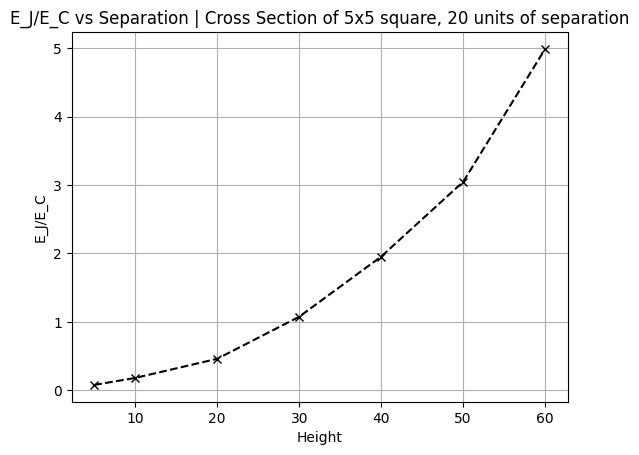

In [3]:
def fit_curve(heights, ratios):
    # Define the function to fit
    def func(x, a, n):
        return a * (x**n)

    # Initial guess for the parameters
    initial_guess = [1, 1]

    # Perform the fit
    popt, _ = curve_fit(func, heights, ratios, p0=initial_guess)

    return popt

popt = fit_curve(heights,ratios)
print(f"Degree of Polynomial Fit: {popt[1]}")

plt.plot(heights,ratios,"x--",color="black")
plt.xlabel("Height")
plt.ylabel("E_J/E_C")
plt.title("E_J/E_C vs Separation | Cross Section of 5x5 square, 20 units of separation")
plt.grid(True)

In [15]:
print(e_js)
print(e_cs)

[Array(0.20309448, dtype=float32), Array(0.20046616, dtype=float32), Array(0.16688156, dtype=float32), Array(0.15429306, dtype=float32), Array(0.13246536, dtype=float32), Array(0.12210846, dtype=float32), Array(0.1149292, dtype=float32), Array(0.10881805, dtype=float32), Array(0.08768845, dtype=float32), Array(0.09562683, dtype=float32), Array(0.08723068, dtype=float32), Array(0.08470154, dtype=float32), Array(0.08142853, dtype=float32), Array(0.08819199, dtype=float32), Array(0.08089828, dtype=float32), Array(0.06384277, dtype=float32), Array(0.07585144, dtype=float32), Array(0.06487656, dtype=float32), Array(0.07102966, dtype=float32), Array(0.07252884, dtype=float32)]
[Array(0.00154019, dtype=float32), Array(0.00152773, dtype=float32), Array(0.00156927, dtype=float32), Array(0.00157881, dtype=float32), Array(0.00158518, dtype=float32), Array(0.00162073, dtype=float32), Array(0.00164377, dtype=float32), Array(0.00166157, dtype=float32), Array(0.00168401, dtype=float32), Array(0.00168

## Plot Accuracy of Integrated Volume

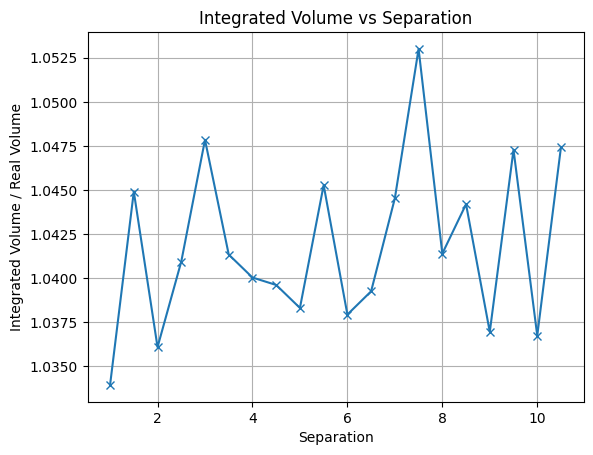

In [16]:
real_volume = 25**3 * 2

volume_ratios = np.array(integrated_volumes) / real_volume

plt.plot(separations,volume_ratios,"x-")
plt.xlabel("Separation")
plt.ylabel("Integrated Volume / Real Volume")
plt.title("Integrated Volume vs Separation")
plt.grid(True)

# Plot the Coefficient Distribution vs Separation

/tmp/ipykernel_899221/1748460017.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


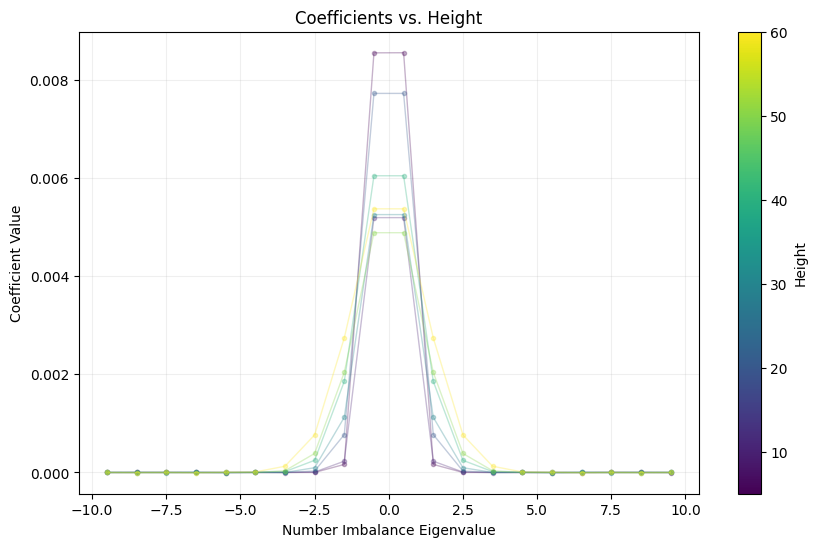

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Assuming:
# coeffs_array: 2D array/list of vectors
# separations: 1D array of values used for the colormap
# n: the number of coefficients (to define the x-axis)

# 1. Define the x-axis (Number Imbalance Eigenvalues)
n = 20
x_axis = (n - 1) / 2 - np.arange(n)

# 2. Setup Figure and Colormap
fig, ax = plt.subplots(figsize=(10, 6))
cmap = cm.get_cmap('viridis')
norm = plt.Normalize(vmin=np.min(heights), vmax=np.max(heights))

# 3. Plot each vector in the array
for i, height in enumerate(heights):

    line_color = cmap(norm(height))

    # Get only the middle n coefficients for plotting
    coeffs = coeffs_array[i]
    if len(coeffs) > n:
        start_idx = (len(coeffs) - n) // 2
        coeffs = coeffs[start_idx:start_idx + n]
    
    # Then normalize the coefficients
    coeffs = coeffs / jnp.sqrt(jnp.sum(coeffs**2))

    ax.plot(x_axis, coeffs, 
            color=line_color, 
            marker="o", 
            linestyle="-", 
            alpha=0.3,      # Transparency to see overlaps
            linewidth=1, 
            markersize=3)

# 4. Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Height')

# 5. Labels
ax.set_title('Coefficients vs. Height')
ax.set_xlabel('Number Imbalance Eigenvalue')
ax.set_ylabel('Coefficient Value')
ax.grid(True, alpha=0.2)

plt.show()

# BELOW: Single Run Visualization, moved to `VisualizeSingle3D.ipynb` file

In [ ]:
pickled_obj = {}

with open('./allplots/run1/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]

print(f"EJ: {E_J}, EC: {E_C}, EJ/EC: {E_J/E_C}")
print(f"Parameters: {parameters}")

EJ: 0.06458389759063721, EC: 0.007349113468080759, EJ/EC: 8.787984848022461


: 

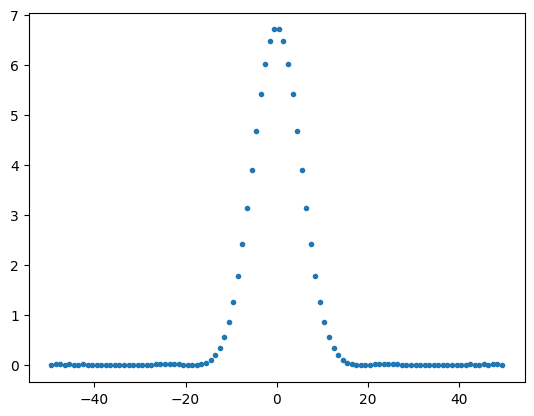

In [3]:
x = (n-1)/2 - jnp.arange(n)
plt.plot(x,coeffs,".")
# femsystem.plot_at_inteRior_2d(theta_at_dofs[femsystem.interior_dofs])
# femsystem.plot_at_interior_2d_in3d(u_odd_interior,plot_title="Odd Mode")
# femsystem.plot_at_interior_2d_in3d(u_even_interior,plot_title="Even Mode")

V min to max: -0.012100624 0.012100624


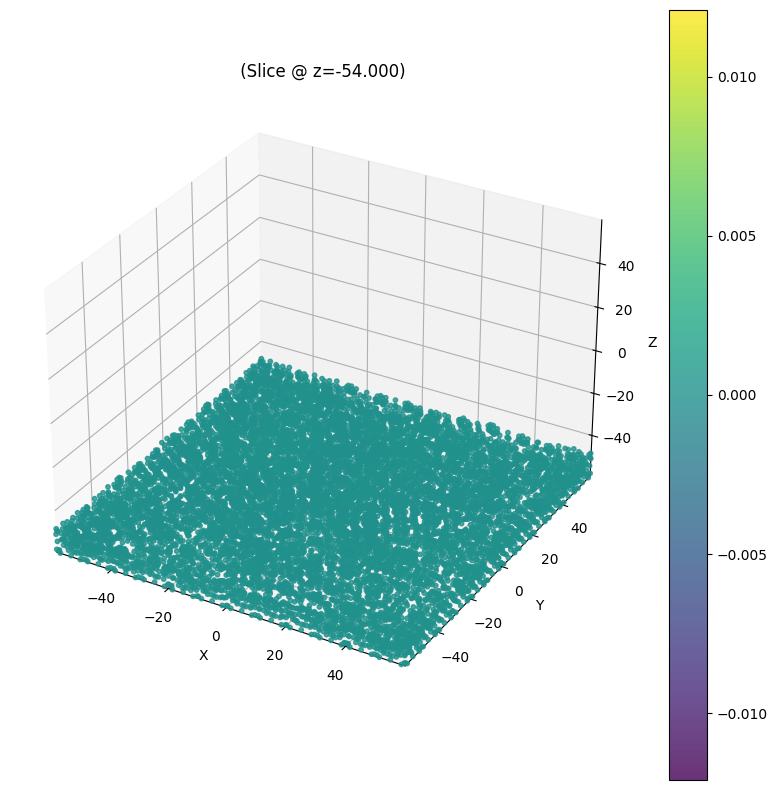

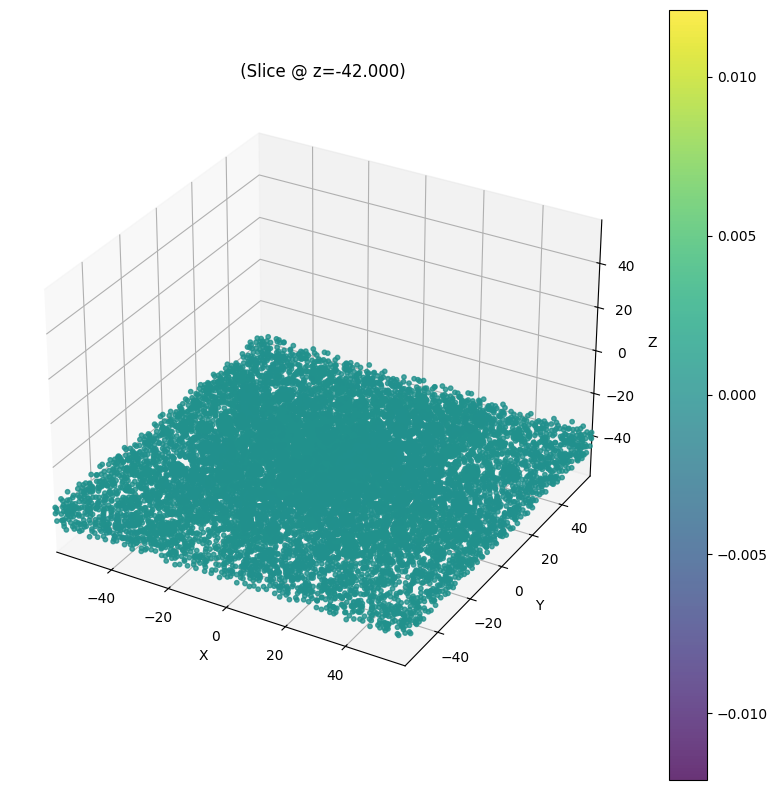

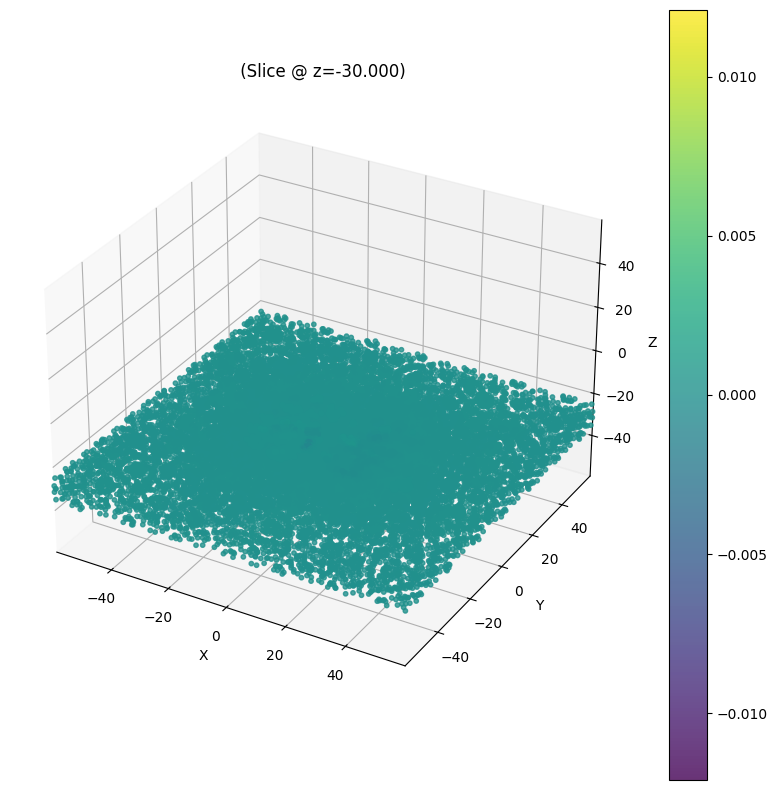

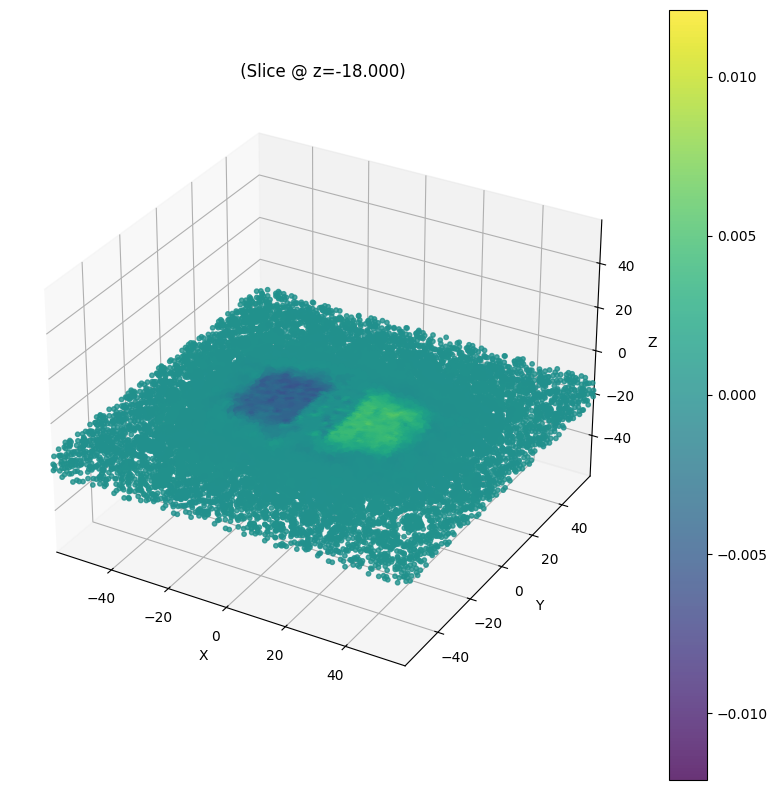

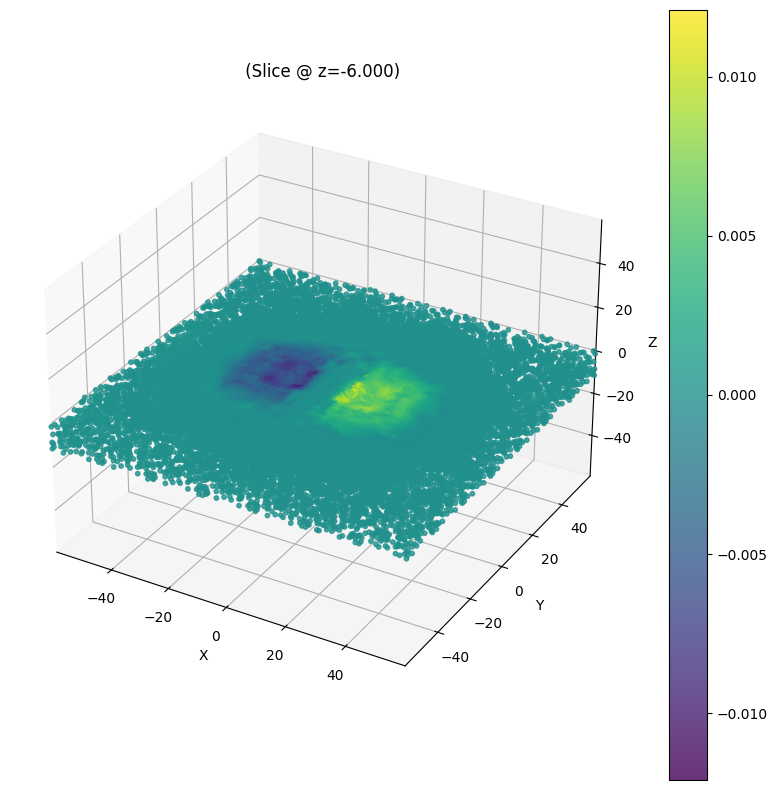

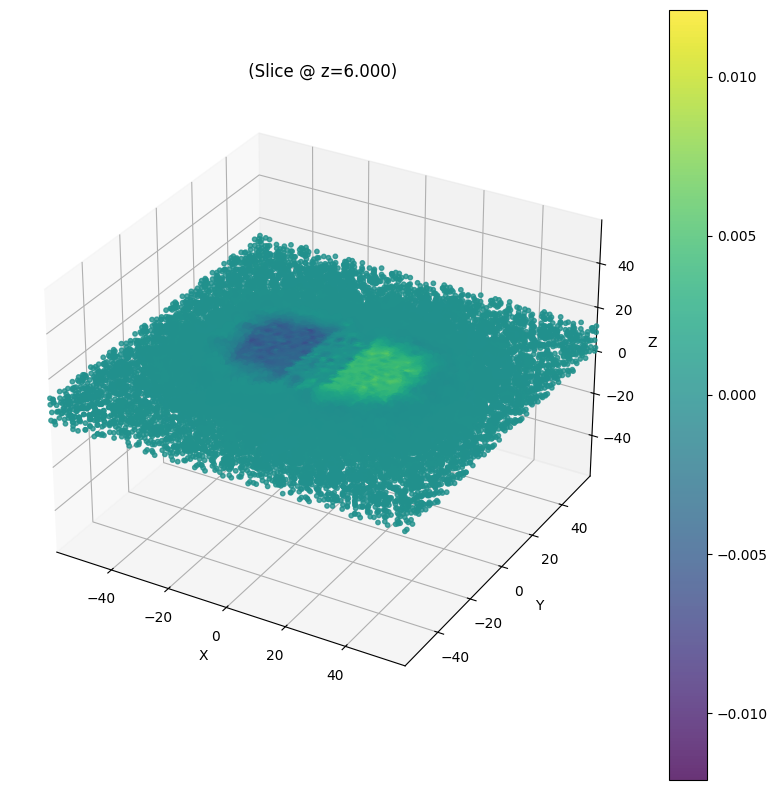

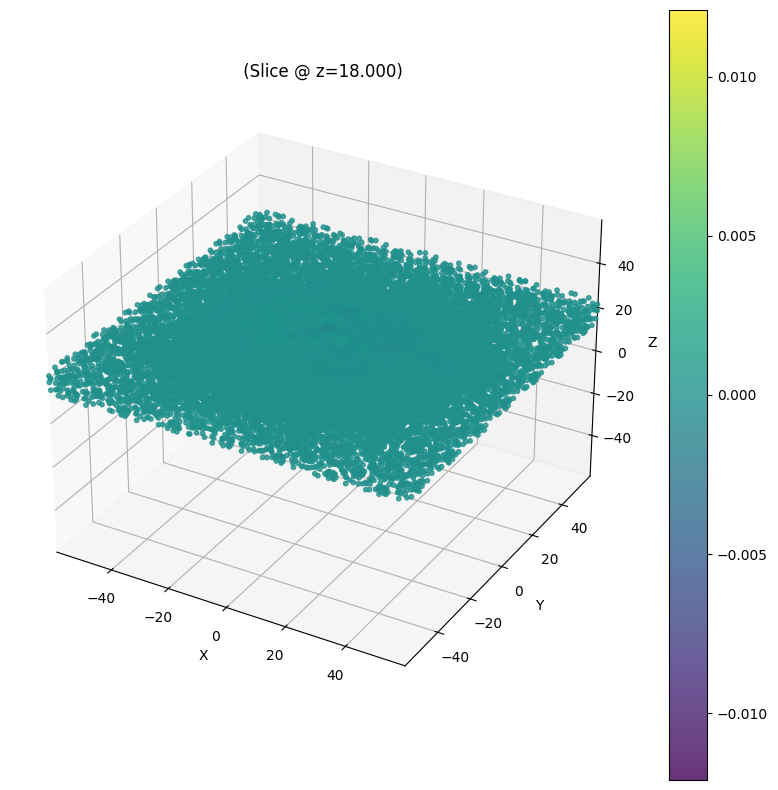

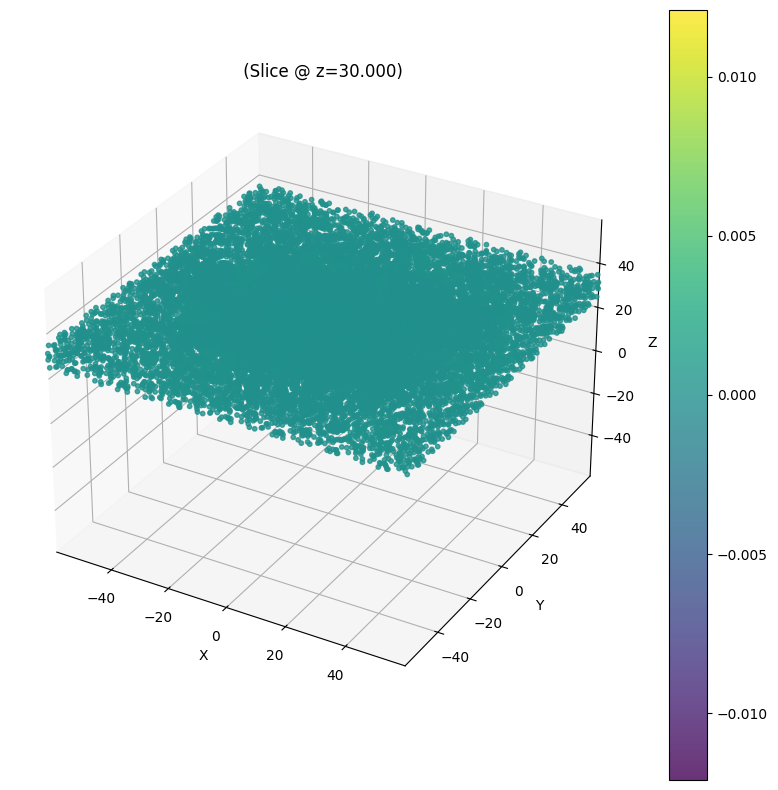

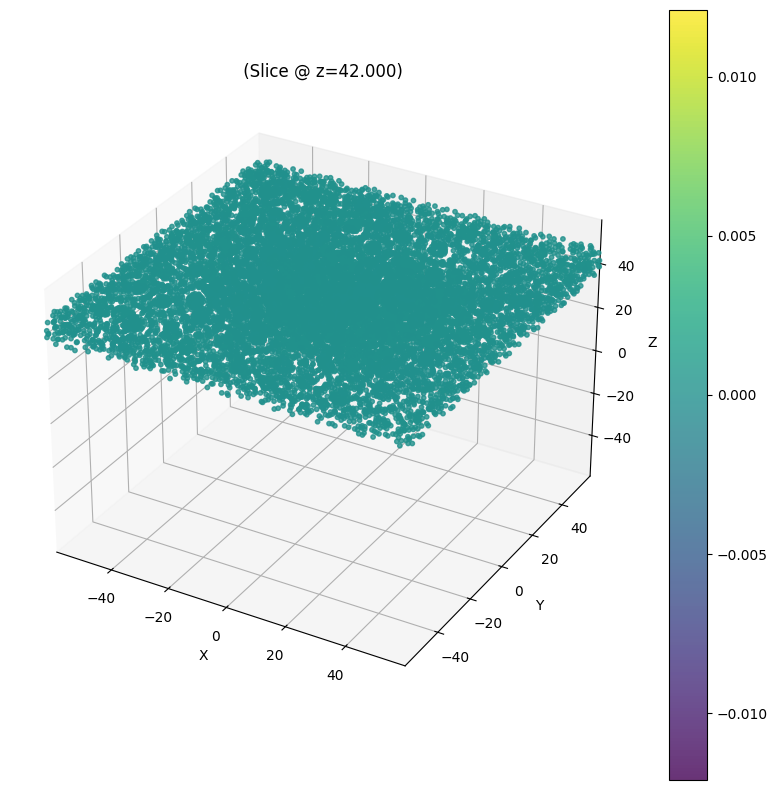

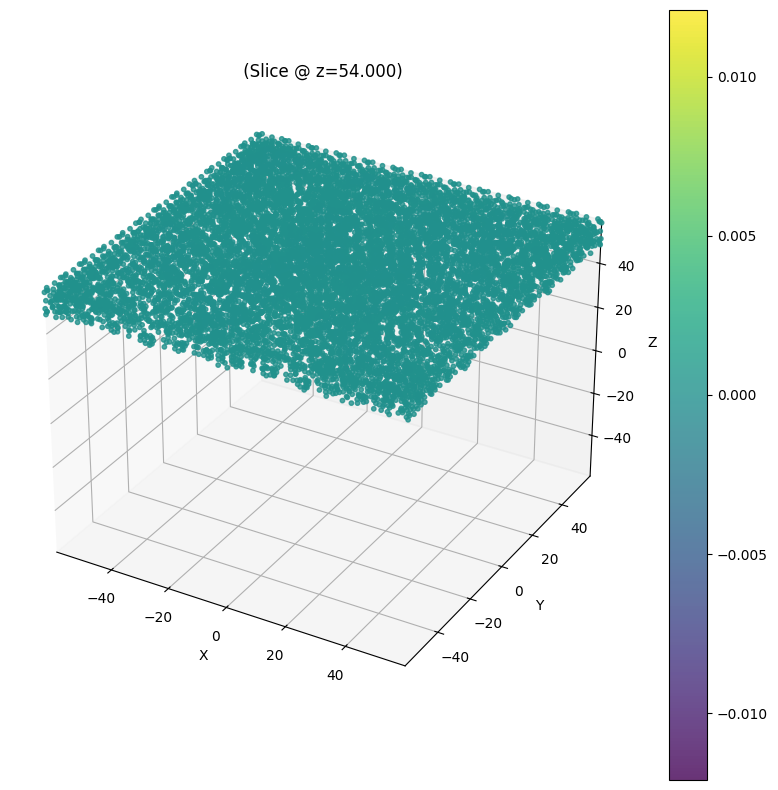

In [4]:
femsystem.plot_n_slices_interior(u_odd_interior,n_slices=10)

V min to max: -0.00013757413 0.0062988256


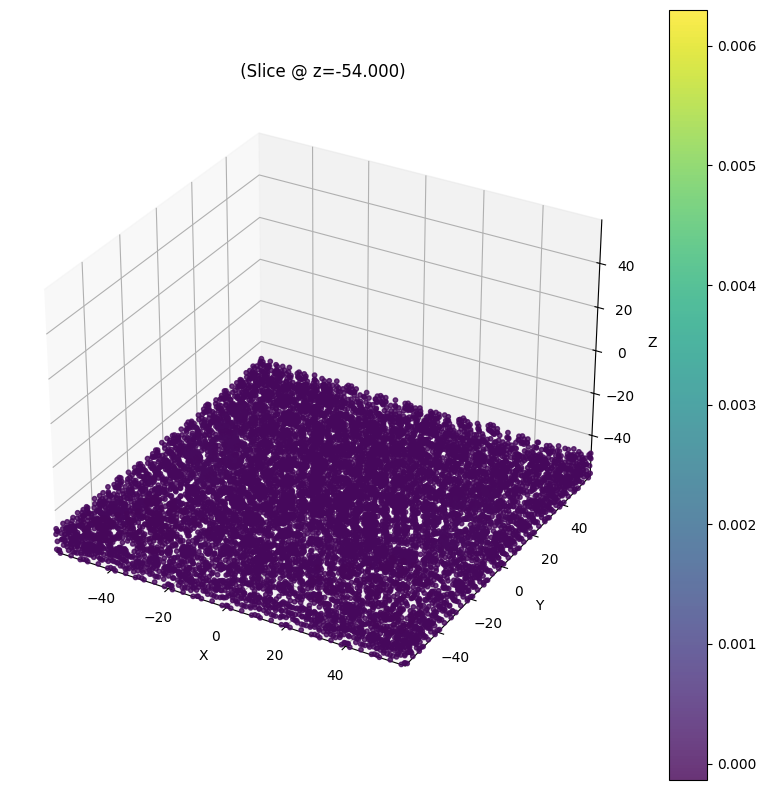

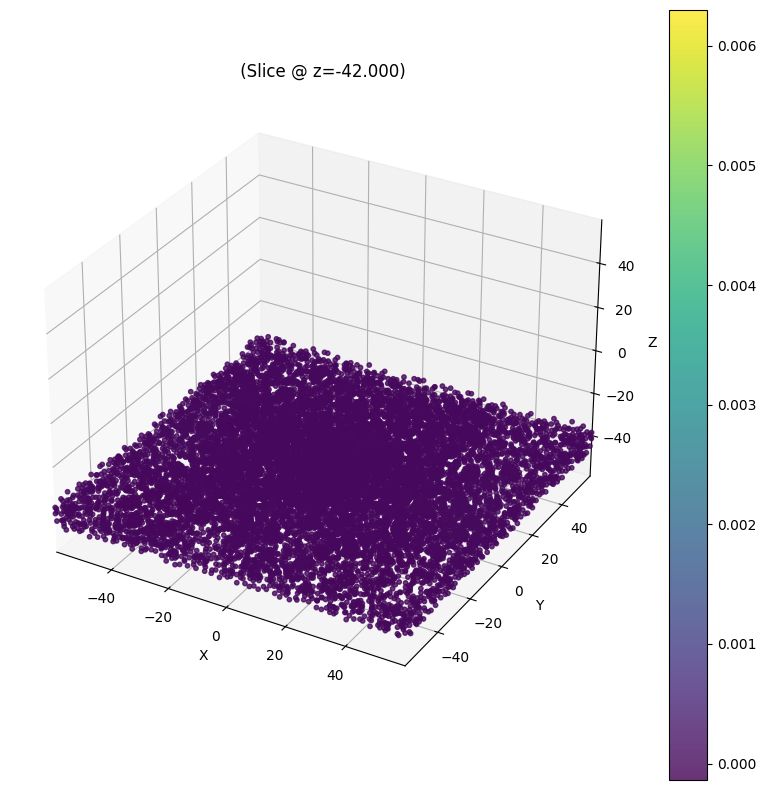

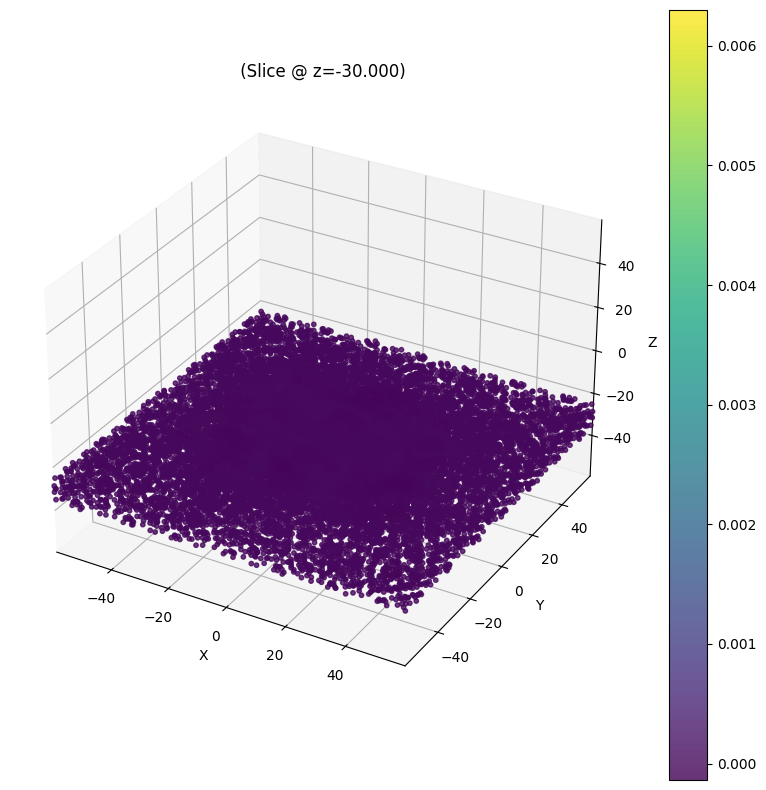

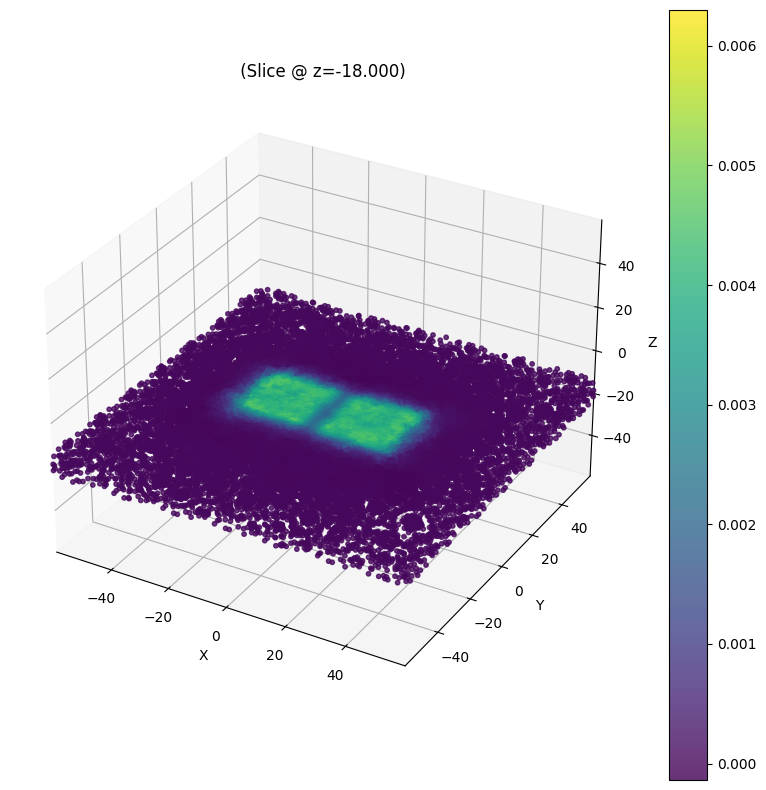

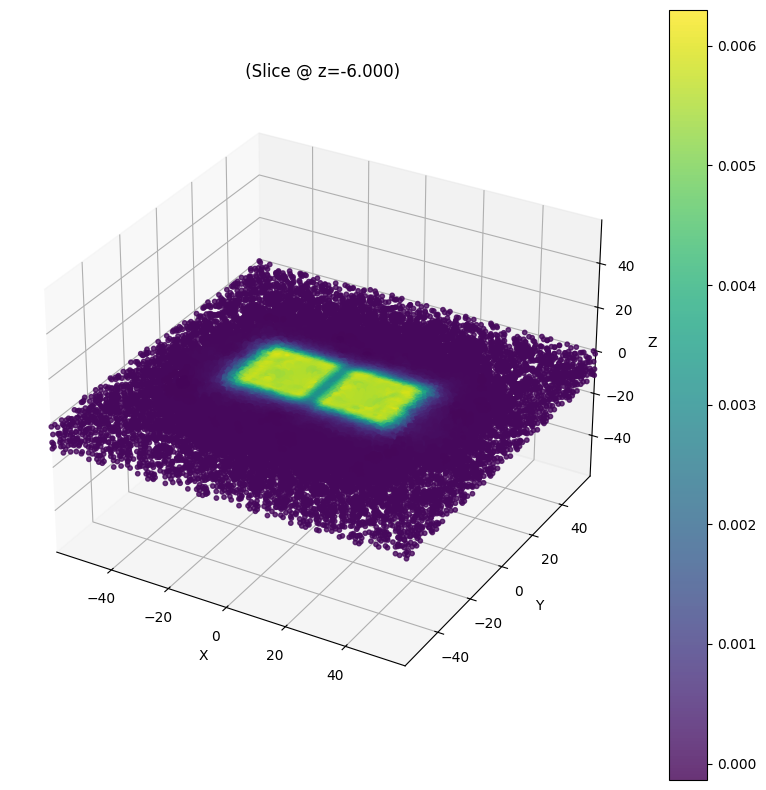

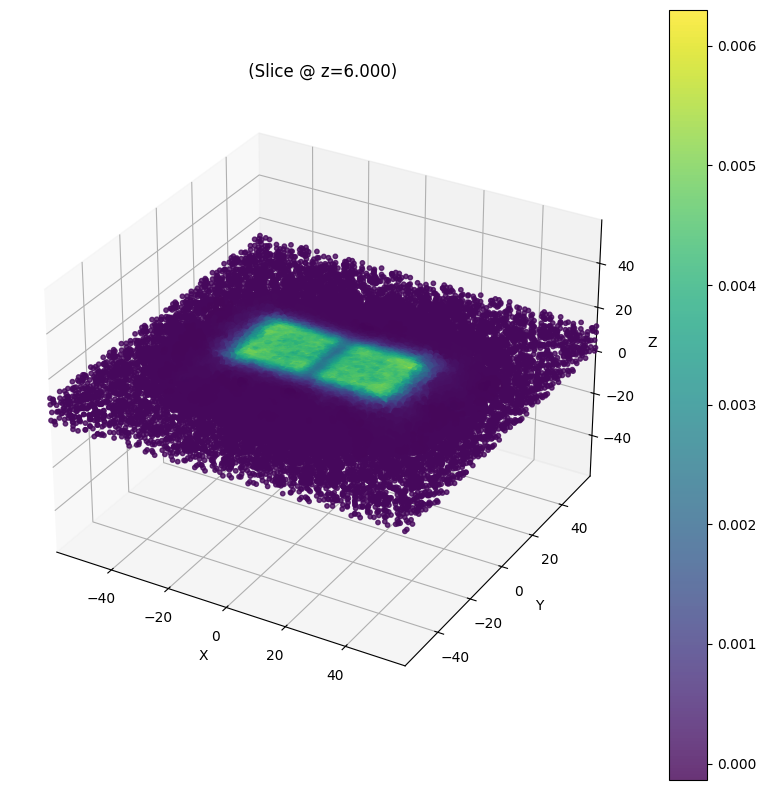

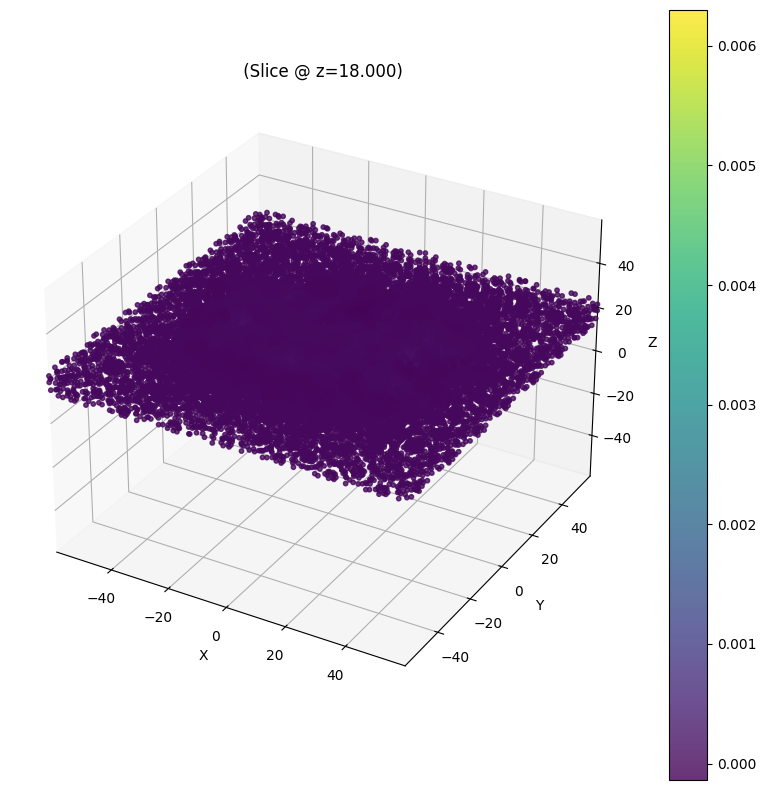

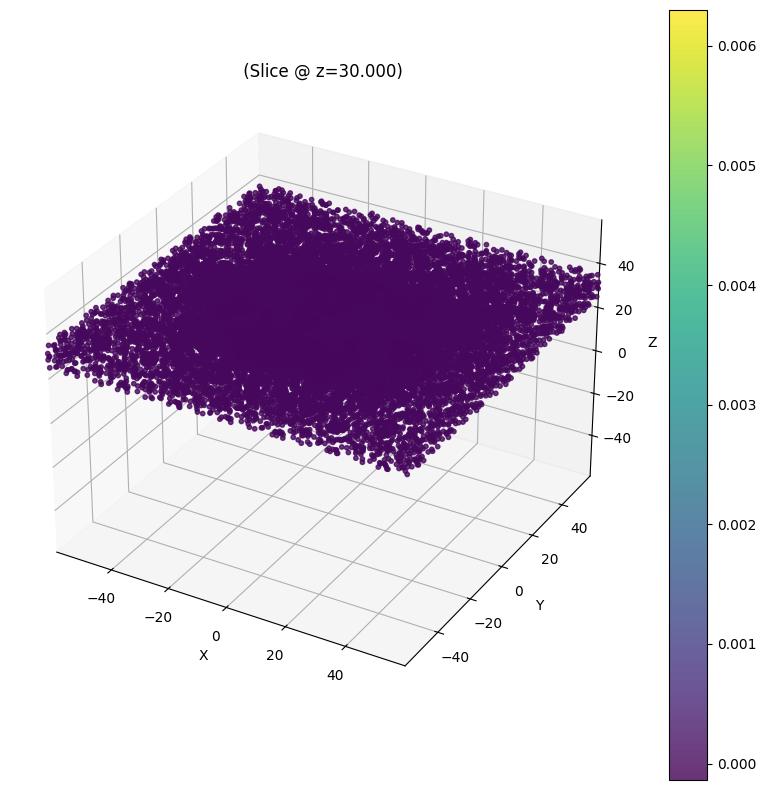

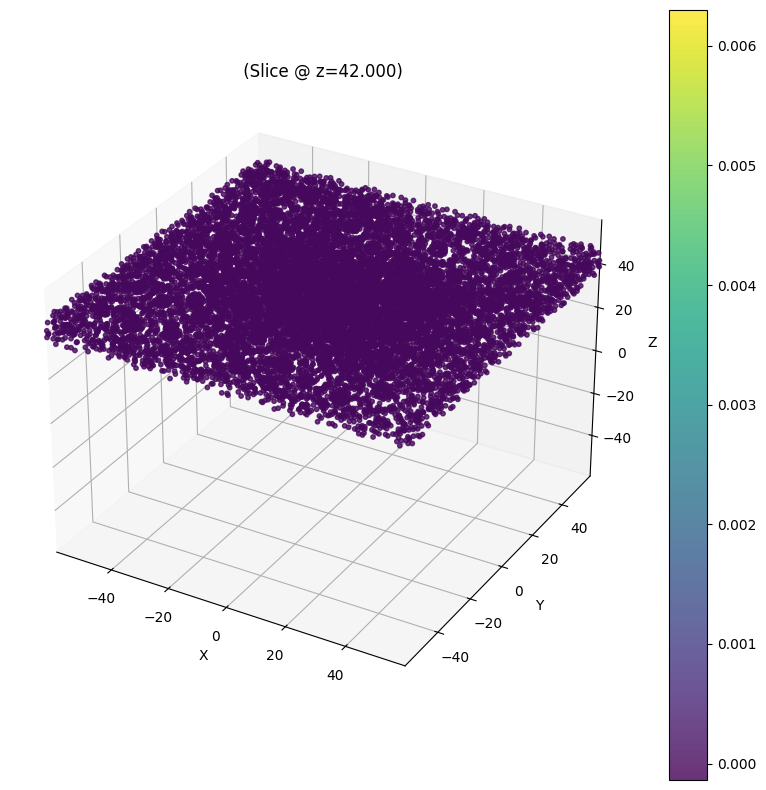

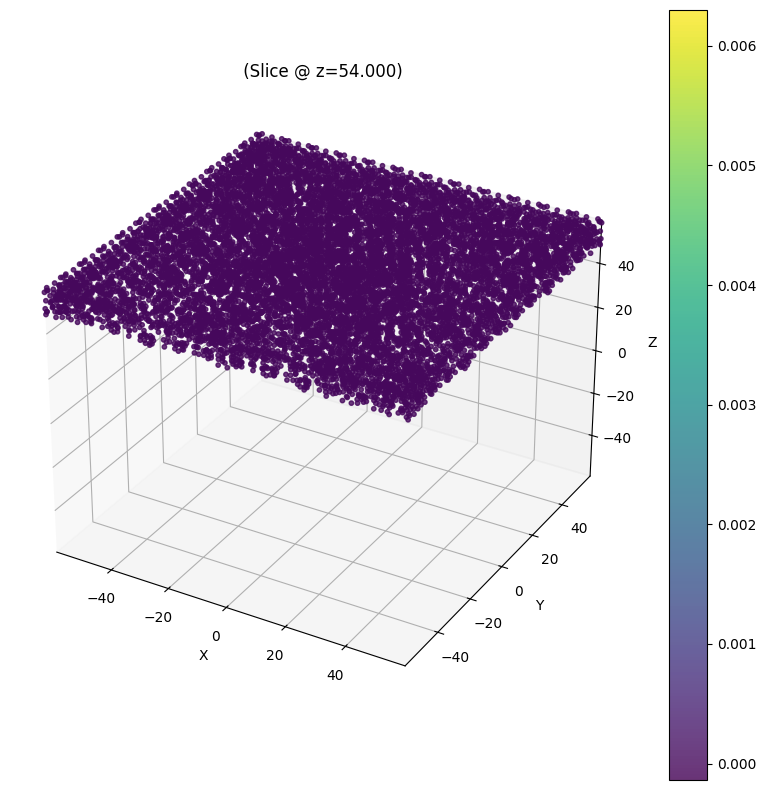

In [5]:
femsystem.plot_n_slices_interior(u_even_interior,n_slices=10)

# Plot the Geometry

V min to max: 0.0 1.0


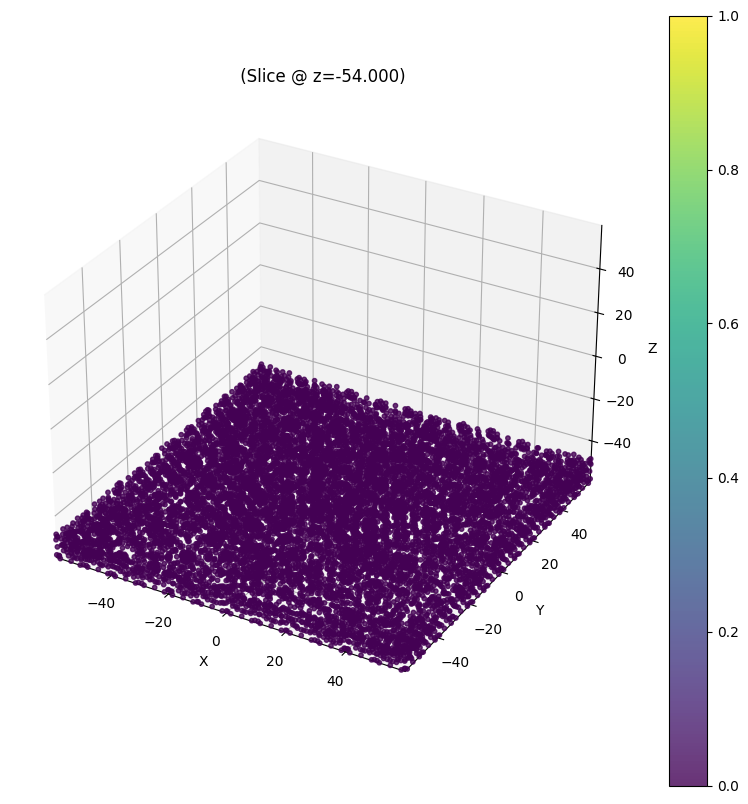

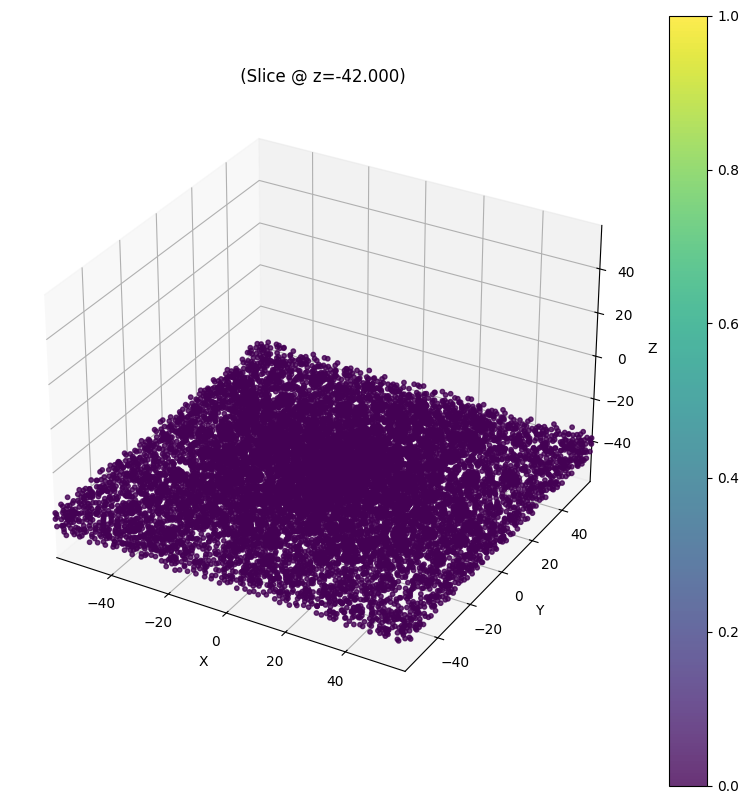

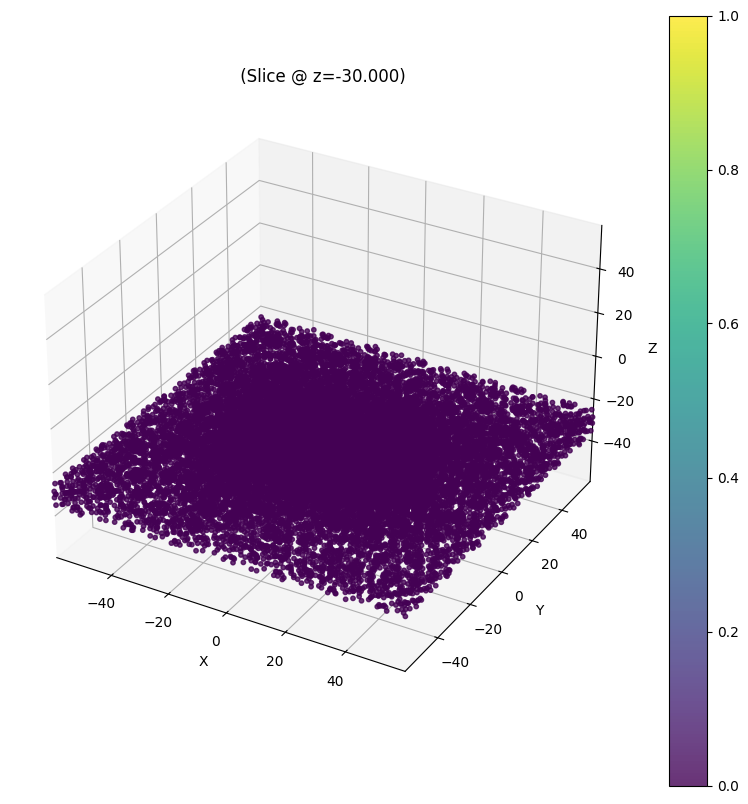

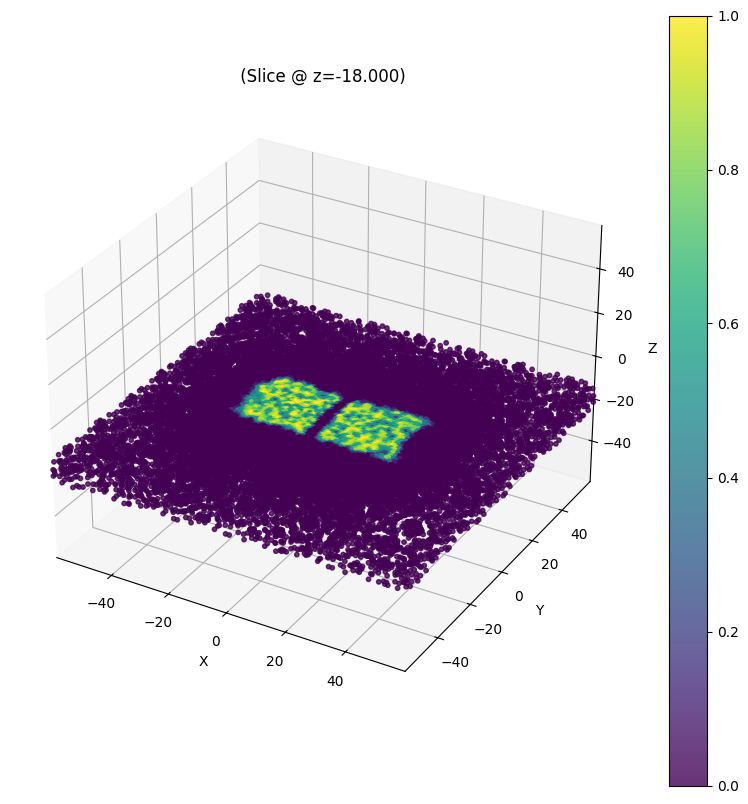

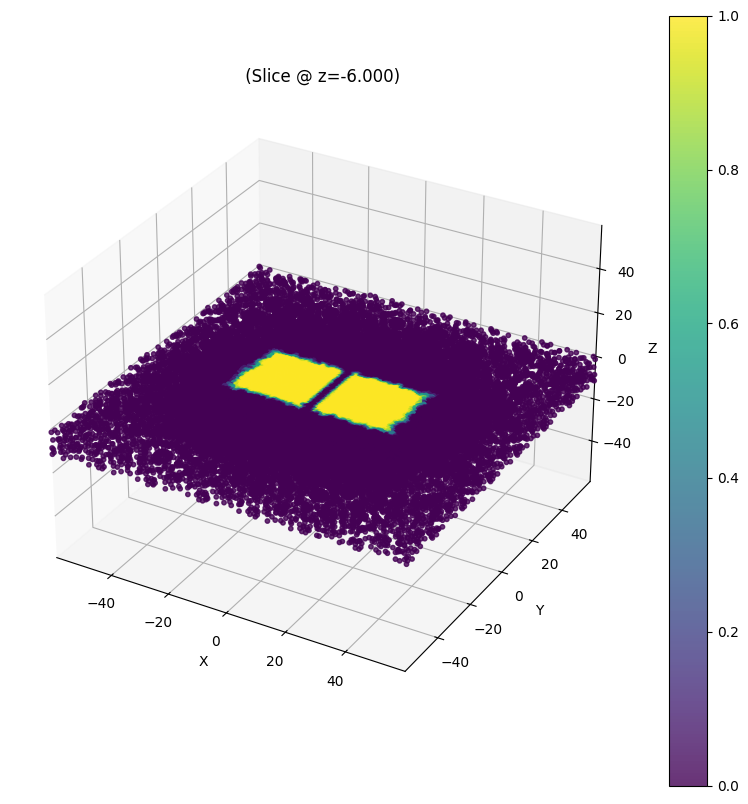

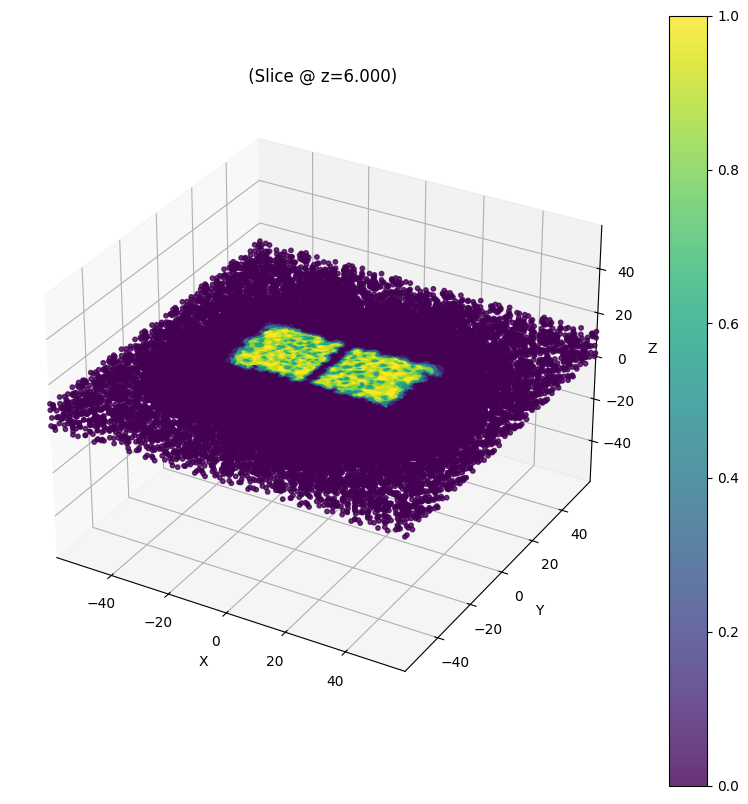

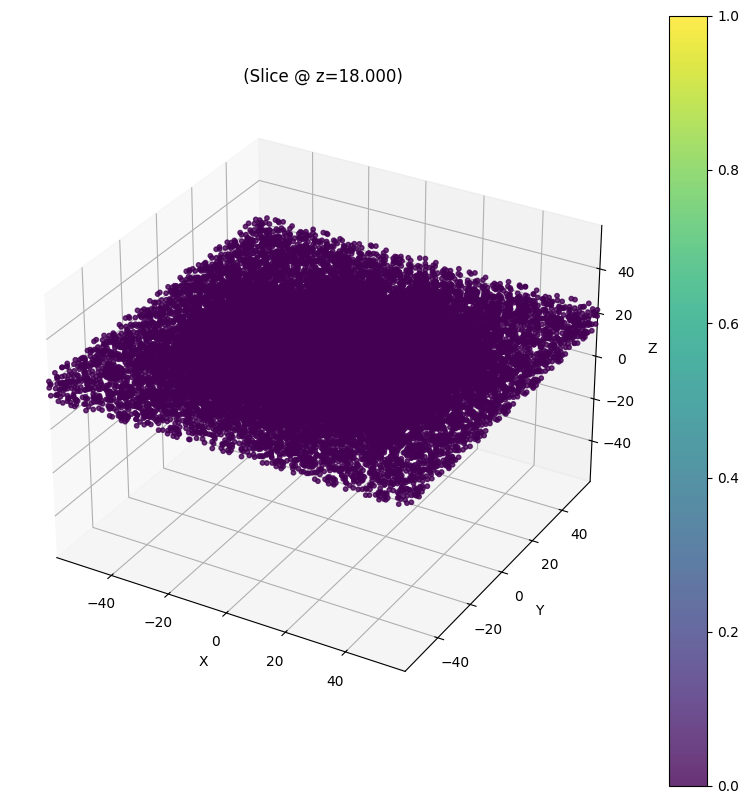

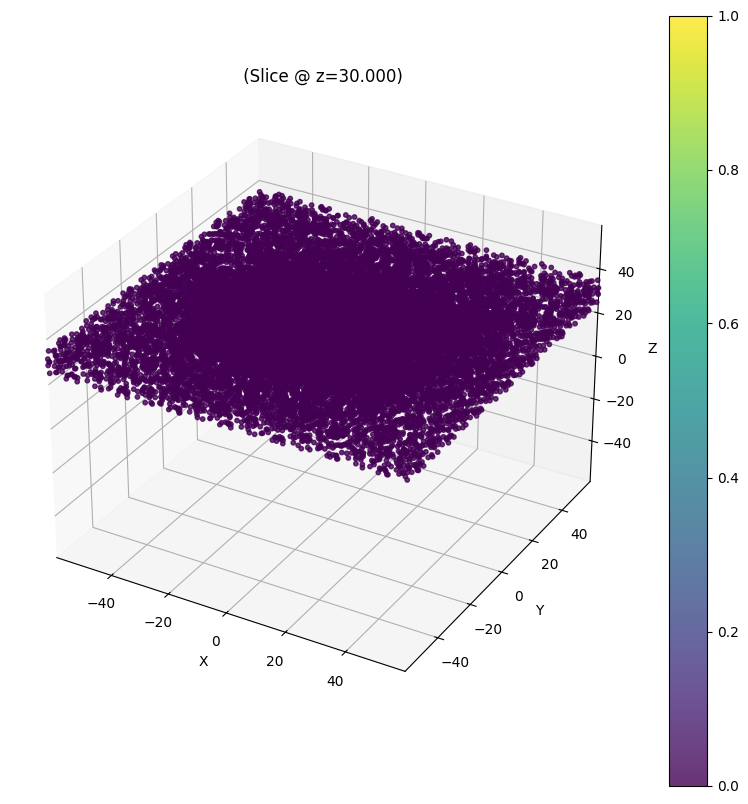

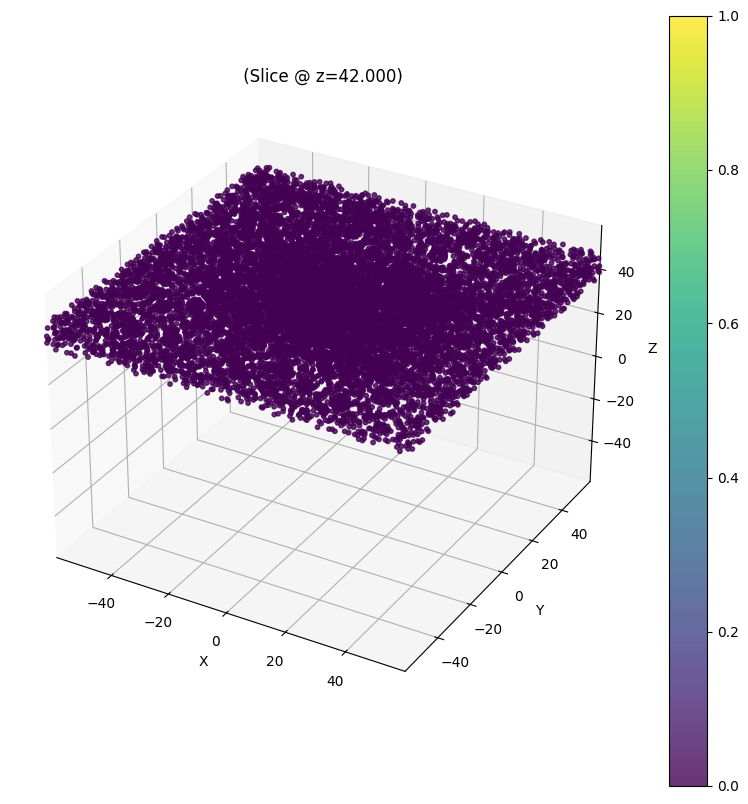

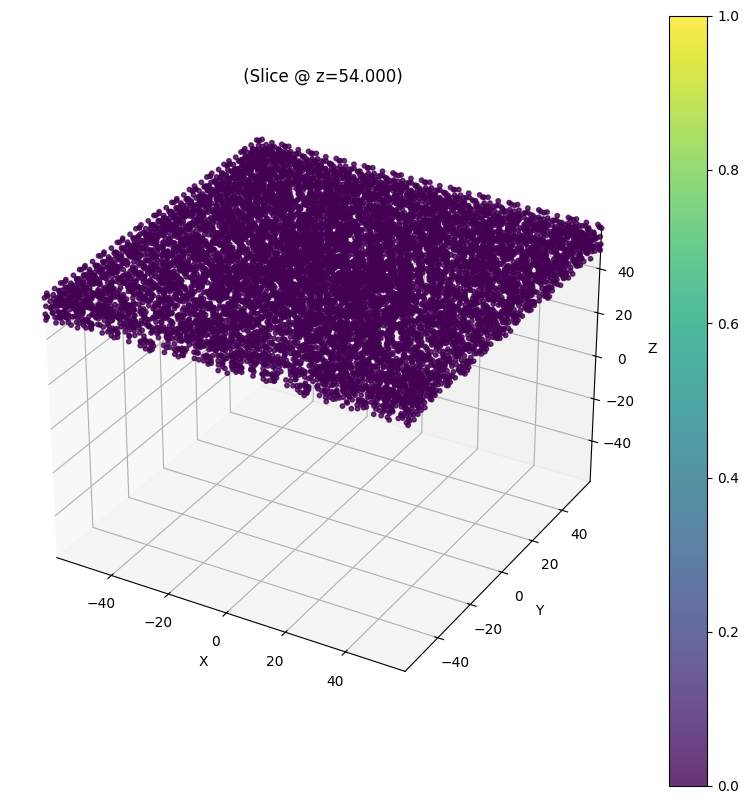

: 

In [ ]:
femsystem.plot_n_slices_interior(theta_at_interior,n_slices=10)